In [8]:
import os
#os.chdir("..") 

✅ Model Hyperparameters:
n_estimators: 150
max_depth: None
max_features: log2
random_state: 42
class_weight: balanced

✅ Metrics:
Accuracy: 0.7964
F1 Score: 0.5603


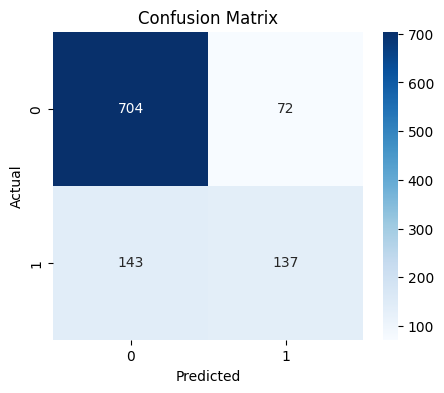


Metrics and hyperparameters appended to metrics/random_forest_metrics.csv


In [9]:
# 1️⃣ Imports
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from src.data_ingestion import load_processed_data
from src.preprocessing import preprocess_data

# 2️⃣ Load processed data & model
df = load_processed_data()
X_train, X_val, X_test, y_train, y_val, y_test, scaler = preprocess_data(df)
model = joblib.load("models/random_forest_model.pkl")

# 3️⃣ Predict on validation set
y_pred = model.predict(X_val)

# 4️⃣ Compute metrics
acc = accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)

print("✅ Model Hyperparameters:")
for p in ["n_estimators", "max_depth", "max_features", "random_state", "class_weight"]:
    print(f"{p}: {model.get_params()[p]}")

print("\n✅ Metrics:")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")

# 5️⃣ Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 6️⃣ Save metrics & hyperparameters (append mode)
metrics_df = pd.DataFrame({
    "accuracy": [acc],
    "f1_score": [f1],
    "n_estimators": [model.get_params()["n_estimators"]],
    "max_depth": [model.get_params()["max_depth"]],
    "max_features": [model.get_params()["max_features"]],
    "random_state": [model.get_params()["random_state"]],
    "class_weight": [model.get_params()["class_weight"]],
})

metrics_file = "metrics/random_forest_metrics.csv"
# Append if exists, else create new
if os.path.exists(metrics_file):
    metrics_df.to_csv(metrics_file, mode='a', header=False, index=False)
else:
    metrics_df.to_csv(metrics_file, index=False)

print("\nMetrics and hyperparameters appended to metrics/random_forest_metrics.csv")
